In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/data-science-int-20-h-2026-test-task/hackathon_int20h_dataset_test.csv


# Робимо базовий аналіз даних

In [2]:
df_path = "/kaggle/input/data-science-int-20-h-2026-test-task/hackathon_int20h_dataset_test.csv"
data_raw = pd.read_csv(df_path)
df_raw = pd.DataFrame(data_raw)

# 1. Чистка данних

In [3]:
df_clean = df_raw.copy()
df_clean["created_at"] = pd.to_datetime(df_clean["created_at"])
df_clean["processed_at"] = pd.to_datetime(df_clean["processed_at"])

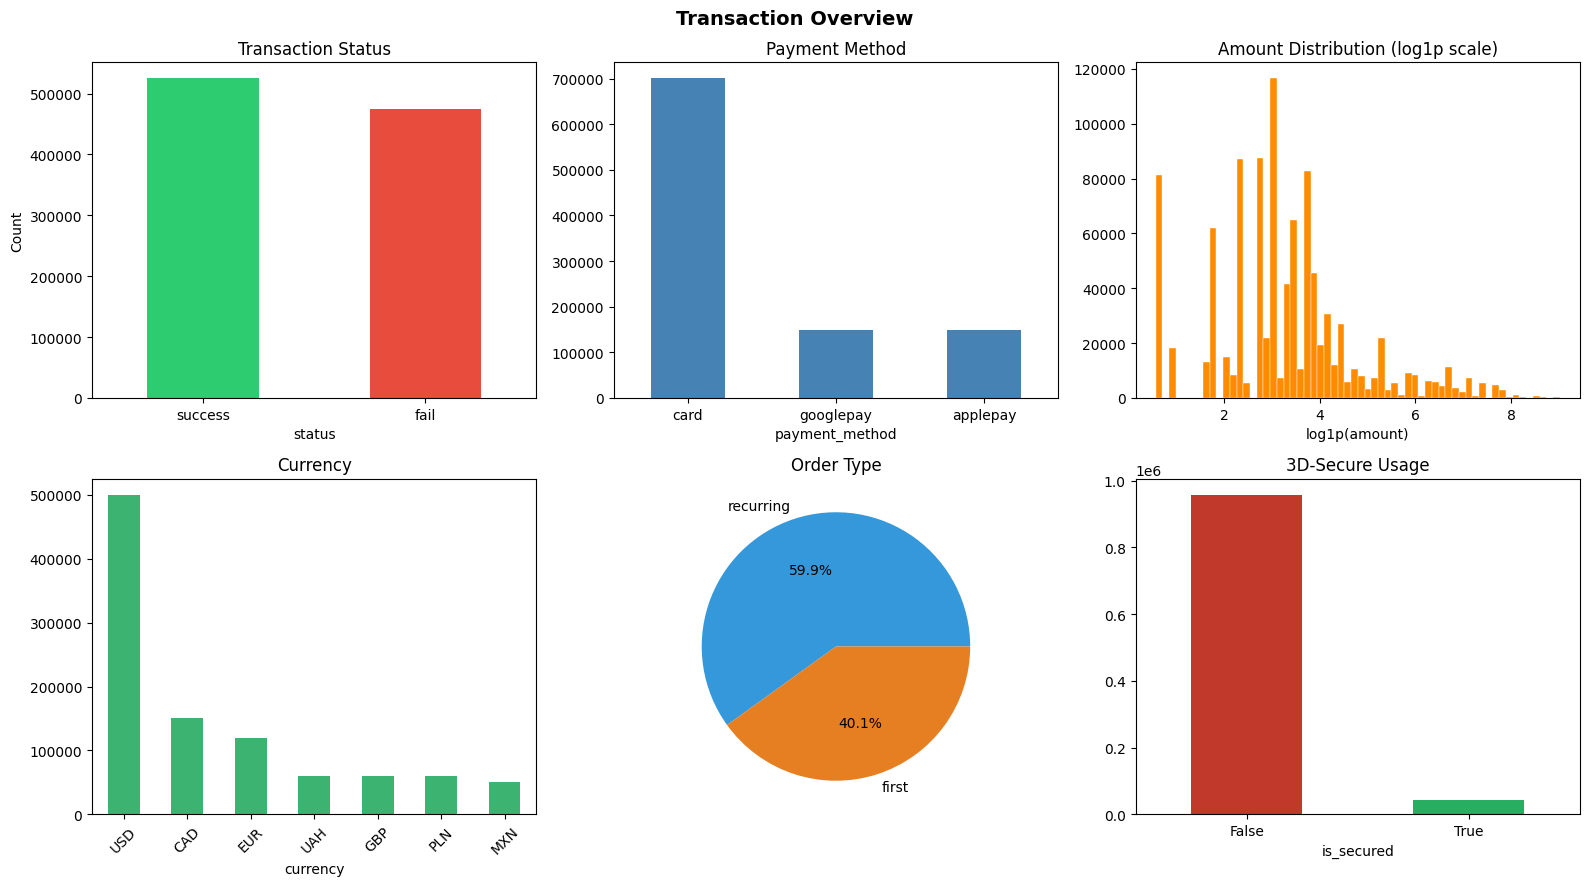

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Transaction Overview', fontsize=14, fontweight='bold')

# Status
df_clean['status'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2ecc71','#e74c3c'], rot=0)
axes[0,0].set_title('Transaction Status')
axes[0,0].set_ylabel('Count')

# Payment method
df_clean['payment_method'].value_counts().plot(kind='bar', ax=axes[0,1], color='steelblue', rot=0)
axes[0,1].set_title('Payment Method')

# Amount distribution (log scale)
axes[0,2].hist(np.log1p(df_clean['amount']), bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
axes[0,2].set_title('Amount Distribution (log1p scale)')
axes[0,2].set_xlabel('log1p(amount)')

# Currency
df_clean['currency'].value_counts().plot(kind='bar', ax=axes[1,0], color='mediumseagreen', rot=45)
axes[1,0].set_title('Currency')

# Order type
df_clean['order_type'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%',
                                      colors=['#3498db','#e67e22'])
axes[1,1].set_title('Order Type')
axes[1,1].set_ylabel('')

# Is secured
df_clean['is_secured'].value_counts().plot(kind='bar', ax=axes[1,2], color=['#c0392b','#27ae60'], rot=0)
axes[1,2].set_title('3D-Secure Usage')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# 2. Фільтрація даних

## Медіанний час транзакії ( processed_at - creates_at )

In [5]:
transaction_time_rows = (df_clean["processed_at"] - df_clean["created_at"]).dt.total_seconds()
median_val = transaction_time_rows.median()
print(median_val)

6.0


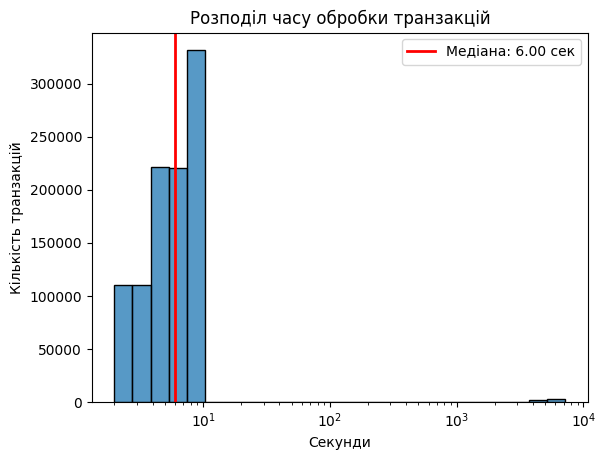

In [6]:
sns.histplot(transaction_time_rows.values, bins=25, log_scale=True)
plt.axvline(median_val, color='red', linestyle='-', linewidth=2, label=f'Медіана: {median_val:.2f} сек')
plt.title('Розподіл часу обробки транзакцій')
plt.xlabel('Секунди')
plt.ylabel('Кількість транзакцій')
plt.legend()
plt.show()

In [7]:
median_cof = 0.2

In [8]:
df_clean["is_in_median_time_tran"] = (
    (transaction_time_rows > median_val * median_cof) & 
    (transaction_time_rows < median_val / median_cof)
)
df_clean["is_in_median_time_tran"].value_counts()

is_in_median_time_tran
True     994567
False      5433
Name: count, dtype: int64

## Перевірки повернень


In [9]:
#dataframe повернення
cond_ref = (
    (df_raw["has_refund"] == True) & (df_raw["amount"] - df_raw["refunded_amount"] < 0)
    | ((df_raw["has_refund"] == False) & (df_raw["refunded_amount"] > 0 ))
)

df_clean["is_valide_refund"] = cond_ref
df_clean["is_valide_refund"] = ~df_clean["is_valide_refund"]
df_clean.head()

,created_at,order_id,processed_at,order_type,user_id,ip_country,currency,amount,payment_method,order_payment_type,bin_country,bank_id,psp_id,has_refund,refunded_amount,is_secured,status,error_code,is_in_median_time_tran,is_valide_refund
0,2025-07-01 09:21:23,1,2025-07-01 09:21:32,first,692925,DEU,EUR,4.60,googlepay,NaN,GBR,32,psp_alpha,False,0.0,False,fail,3.02,True,True
1,2025-09-01 01:15:47,2,2025-09-01 01:15:57,recurring,452913,CAN,CAD,54.80,card,recurring,CAN,1,psp_alpha,False,0.0,False,success,NaN,True,True
2,2025-06-24 23:38:35,3,2025-06-24 23:38:39,first,784680,USA,USD,9.99,card,NaN,USA,32,psp_alpha,False,0.0,False,fail,2.01,True,True
3,2025-04-23 04:42:13,4,2025-04-23 04:42:21,first,300037,CAN,CAD,1.37,card,NaN,CAN,31,psp_gamma,False,0.0,False,fail,3.04,True,True
4,2025-03-14 20:15:32,5,2025-03-14 20:15:42,first,996803,DEU,EUR,0.92,card,NaN,GBR,39,psp_beta,False,0.0,False,fail,2.12,True,True


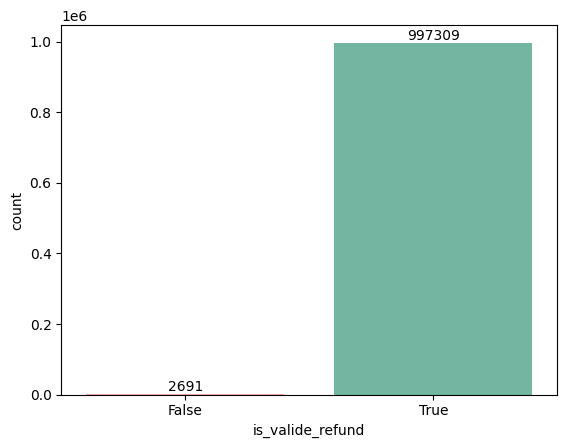

In [10]:
counts = df_clean["is_valide_refund"].value_counts()
ax = sns.countplot(
    data=df_clean,
    x="is_valide_refund",
    palette=["#ff9999", "#66c2a5"],        
    order=[False, True],      
    hue="is_valide_refund",   
    legend=False
)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

## Amount above 100

In [11]:
cur_cor_to_usd = {
    "EUR": 1.18,
    "USD": 1,
    "CAD": 0.73,
    "UAH": 0.023,
    "PLN": 0.28,
    "MXN": 0.058,
    "GBP": 1.35
}
rate = df_clean["currency"].map(cur_cor_to_usd)
df_clean["amount_usd"] = df_clean["amount"] * rate

In [12]:
# Тобто уточнене правило:
df_clean["is_amount_above_100"] = (
    (df_clean["amount_usd"] > 100) &
    ~(
        (df_clean["status"] == "success") &
        (df_clean["order_payment_type"].isin(["rebill", "recurring", "retry"]))
    )
)
df_clean["is_amount_above_100"].value_counts()

is_amount_above_100
False    982462
True      17538
Name: count, dtype: int64

<Axes: >

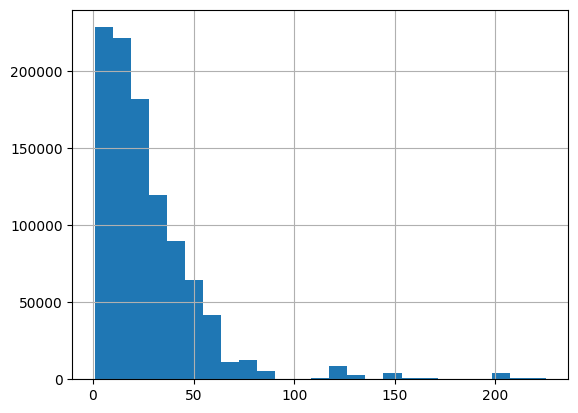

In [13]:
df_clean["amount_usd"].hist(bins=25)

## Помилки з 3DS і is_secured, що просто підтверджує, що перевірку пройшло

In [14]:
error_3ds = [2.10,2.11,2.12,2.15,3.01,3.09,3.13,4.04,]

eror_cond = ((df_clean["is_secured"] == True) & df_clean["error_code"].isin(error_3ds))
df_clean["not_valide_3DS"] = eror_cond
eror_cond.value_counts()

False    996052
True       3948
Name: count, dtype: int64

## Повернення при статусу провальній транзакції

In [15]:
df_clean["refund_error"] = ((df_clean["error_code"].notna()) & (df_clean["has_refund"] == True) & (df_clean["refunded_amount"] > 0))
df_clean["refund_error"].value_counts()

refund_error
False    998701
True       1299
Name: count, dtype: int64

# Підготовка фінальних результатів

In [16]:
df_clean["is_anomaly"] = (
    ~df_clean["is_in_median_time_tran"] |
    ~df_clean["is_valide_refund"] |
    df_clean["is_amount_above_100"] |
    df_clean["not_valide_3DS"] |
    df_clean["refund_error"] |
    (df_clean["bank_id"] == 777)
)
df_result = df_clean[["order_id", "is_anomaly"]]
df_result.sort_values(by="order_id")
df_result["is_anomaly"].value_counts()
df_result.to_csv("submission.csv", index=False)

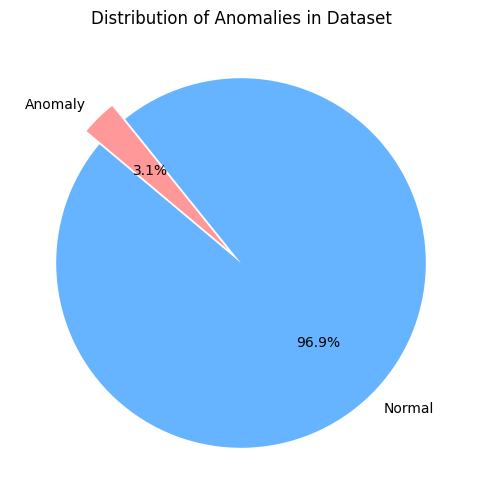

In [17]:
anomaly_counts = df_clean['is_anomaly'].value_counts()
labels = ['Normal', 'Anomaly']
colors = ['#66b3ff', '#ff9999'] # Блакитний та ніжний червоний


plt.figure(figsize=(8, 6))
plt.pie(anomaly_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0, 0.1))

plt.title('Distribution of Anomalies in Dataset')
plt.show()